# Implied Volatility and Smile Interpolation

This project implements Black–Scholes call pricing, recovers implied
volatility using bisection and Newton's method, and reconstructs a
synthetic volatility smile using Lagrange interpolation.

The methods are implemented from scratch to apply numerical root-finding
and polynomial interpolation to an option-pricing problem.

In [31]:
import numpy as np
from scipy.stats import norm
import matplotlib.pyplot as plt

#Call Price function
def call_bs(S,K,T,r, sigma) :
    d1 = (np.log(S/K) + (r + (sigma**2/2))*T)/(sigma*np.sqrt(T))
    d2 = d1 - sigma*np.sqrt(T)
    return S*norm.cdf(d1) - K*np.exp(-r*T)*norm.cdf(d2)

#exemple value 
S, K, T, r = 100, 100, 1, 0.02
C_marche = 10

#Function for which the difference is 0 when the calculated call is equal to the market price
def f(sigma) :
    return call_bs(S,K,T,r, sigma) - C_marche




## Recovering implied volatility

Implied volatility is the volatility that makes the Black–Scholes
price equal to an observed option price:

$$
C_{BS}(S,K,T,r,\sigma)-C_{\mathrm{market}}=0.
$$

Bisection repeatedly halves an interval containing the root.
Newton's method uses vega, the derivative of the call price with
respect to volatility:

$$
\sigma_{n+1}
=
\sigma_n-
\frac{C_{BS}(\sigma_n)-C_{\mathrm{market}}}
{\mathrm{Vega}(\sigma_n)}.
$$

In the initial example, bisection required 20 iterations and Newton
required 2. Both recovered an implied volatility of approximately
22.77%. If we have to make huge computations, we can start with a 
Bisection to find a good point which gets closer to the solution 
and after such iterations, we can use the Newton method to remove 
the risk of a bad initialization that can make the algorithm never converge.
Their stopping criteria differ: interval width for bisection
and absolute pricing error for Newton.

In [32]:
#Dichotomie
#we should choose a and b as f(a)f(b)<0
print(f(0.01))
print(f(1.0))

a = 0.01
b = 1.0
m = (a + b) /2
def vol_implicit_dichotomie(S, K, T, r, C_marche, a, b, tol):
    def f(sigma) :
        return call_bs(S,K,T,r, sigma) - C_marche
    if f(a) == 0 :
        m = a
        return m
    if f(b) == 0 :
        m = b
        return m
    if f(a)*f(b) > 0 :
        raise ValueError("The root is not enclosed in a box.")
    m = (b + a) /2
    i = 0
    while b-a > tol:
        i= i + 1
        if f(m) >= 0:
            b = m
        else :
            a = m
        m = (a + b)/2
    return m, i

vol_implicit_dichotomie(100,100,1,0.02,10,0.01,1.0,1e-6)

-8.011461194581202
28.91040858503915


(0.22772331714630129, 20)

In [33]:
#Newton 
#Vega
def vega_bs(S,K,T,r, sigma):
    d1 = (np.log(S/K) + (r + (sigma**2/2))*T)/(sigma*np.sqrt(T))
    return S*norm.pdf(d1)*np.sqrt(T)

def vol_implicit_newton(S, K, T, r, C_marche, sigma0, tol, max_iter): 
    def f(sigma) :
        return call_bs(S,K,T,r, sigma) - C_marche
    sigma = sigma0
    i = 0
    while abs(f(sigma)) > tol and i < max_iter:
        v = vega_bs(S,K,T,r, sigma)
        i += 1
        if abs(v) > 1e-10 :
            sigma = sigma - f(sigma) / v
            print(i,sigma,abs(f(sigma)))
        else :
             raise ValueError("Vega is too low")
             
    if abs(f(sigma)) > tol :
                raise ValueError("Newton doesn't converge")
    return sigma

vol_implicit_newton(100, 100, 1, 0.02, 10, 0.2, 1e-8, 100)

1 0.2277198049759625 0.00012613087584867344
2 0.2277230315705129 4.696687483374262e-12


np.float64(0.2277230315705129)

## Synthetic volatility smile

We use S = 100, T = 1 year and r = 3%, with nine equally spaced
strikes between 70 and 130.

The reference volatility curve is:

$$
\sigma_{\mathrm{ref}}(K)
=
0.20+0.8\left(\frac{K}{S}-1\right)^2.
$$

This symmetric smile has a minimum volatility of 20% at K = S.
Synthetic call prices are generated using this curve, then passed
to Newton's method to recover the corresponding implied volatilities.

In [34]:
#Curve
S = 100
T = 1
r = 0.02
sigma0 = 0.2
tol = 1e-8
max_iter = 100

strikes = np.linspace(70, 130, 9)
def vol_reference(K):
    return 0.20 + 0.8 * (K / S - 1)**2

prix_call = []
for K in strikes:
    c = call_bs(S,K,T,r, vol_reference(K))
    prix_call.append(c)

for K, prix in zip(strikes, prix_call):
    print(K, prix)

implicit_vol = []
for K, prix in zip(strikes, prix_call):
    nv = vol_implicit_newton(S, K, T, r, prix, sigma0, tol, max_iter)
    implicit_vol.append(nv)
    
for K, vol in zip(strikes, implicit_vol):
    print(K, vol)






70.0 32.23468490943521
77.5 25.34852420339979
85.0 18.914079396231635
92.5 13.300254392740449
100.0 8.916037278572539
107.5 5.948423188850441
115.0 4.2221999641168715
122.5 3.3792486866209437
130.0 3.1169343429397003
1 0.3179269598055829 0.6627091065216746
2 0.2769531185039918 0.06323179051963734
3 0.27208166316090976 0.0010252083300983372
4 0.2720000232644931 2.9198180584444344e-07
5 0.2720000000000013 3.552713678800501e-14
1 0.24759457501660703 0.12982864321504906
2 0.24062592158902532 0.002262724530353921
3 0.2405000425360578 7.640854846613365e-07
4 0.24050000000000527 8.526512829121202e-14
1 0.21862428996328842 0.01593292253882339
2 0.21800061198343176 1.5603493586979766e-05
3 0.2180000000005916 1.5084822280186927e-11
1 0.20451138727487173 0.00038367325404209396
2 0.2045000000694282 2.339248794669402e-09
1 0.20450287952188764 0.00011352922893337336
2 0.2045000000011151 4.3968384488835e-11
1 0.21826055099701835 0.009435570146678174
2 0.21800004502326506 1.6301863574597064e-06
3 0.21

## Lagrange interpolation

The recovered strike–volatility pairs are used to estimate
volatility between the sampled strikes:

$$
P(K)=\sum_{i=0}^{n-1}\sigma_i L_i(K),
\qquad
L_i(K)=
\prod_{\substack{j=0\\j\ne i}}^{n-1}
\frac{K-K_j}{K_i-K_j}.
$$

The interpolated curve is compared with the reference curve on
a dense grid. The maximum absolute volatility error is also computed.

In [35]:
def lagrange_interpolation(K, strikes, implicit_vol):
    resultat = 0 
    for i in range(len(strikes)):
        L = 1 
        for j in range(len(strikes)):
            if i != j:
                L *= (K - strikes[j])/(strikes[i] - strikes[j])
        resultat += implicit_vol[i] * L
    return resultat

print(lagrange_interpolation(103, strikes, implicit_vol))
print(vol_reference(103))

0.20071999998962214
0.20072


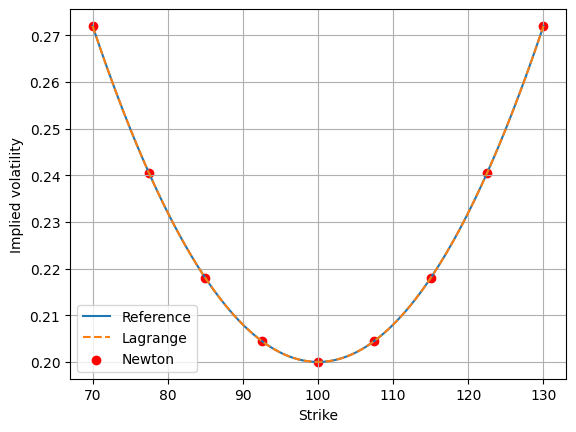

Maximale Error : 2.7453744833039195e-10


In [36]:
K_grille = np.linspace(70, 130, 300)

vol_interpolee = [
    lagrange_interpolation(K, strikes, implicit_vol)
    for K in K_grille
]

import matplotlib.pyplot as plt

plt.plot(K_grille, vol_reference(K_grille), label="Reference")
plt.plot(K_grille, vol_interpolee, "--", label="Lagrange")
plt.scatter(strikes, implicit_vol, color="red", label="Newton")
plt.xlabel("Strike")
plt.ylabel("Implied volatility")
plt.legend()
plt.grid()
plt.show()

erreur = np.abs(np.array(vol_interpolee) - vol_reference(K_grille))
print("Maximale Error :", np.max(erreur))

## Results and limitations

The recovered volatilities match the synthetic reference values,
and the interpolated curve closely follows the reference smile.

The reference function is quadratic, so Lagrange interpolation with
at least three distinct nodes reproduces it exactly in exact arithmetic.
Any observed discrepancy comes from numerical root-finding and
floating-point calculations.

This experiment validates the implementation on synthetic data.
It does not establish accuracy on real market data or guarantee
an arbitrage-free interpolated curve. Newton's method can also fail
when vega is small or an iteration produces a nonpositive volatility.